# 24083010002

# Import Library

In [671]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, LabelEncoder
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.special import inv_boxcox

# Load Dataset

In [672]:
df_train = pd.read_csv('./dataset/train_dataset.csv')
df_test = pd.read_csv('./dataset/test_dataset_no_y.csv')

In [673]:
df_train.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,0.407166,E,W,2.0,M,C,1.127628,-0.657689,-0.415323,76.124758,20.710704
1,44.417166,M,W,1.0,H,C,0.957628,-0.667689,-0.475323,85.834758,94.202404
2,28.047166,M,W,4.0,L,R,0.717628,-1.107689,-0.385323,13.814758,43.043004
3,-0.462834,NaN,W,2.0,L,C,1.717628,-1.547689,-0.425323,29.344758,7.956004
4,42.957166,M,W,3.0,M,C,0.747628,-1.847689,-0.135323,NaN,62.397804


In [674]:
df_test.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10
0,16.787166,N,W,2.0,L,C,2.807628,-0.687689,-0.175323,103.314758
1,38.137166,M,NaN,1.0,M,C,2.197628,-0.617689,-0.195323,14.644758
2,20.797166,E,W,1.0,M,S,3.007628,-0.687689,-0.235323,41.574758
3,15.577166,A,W,4.0,M,C,0.707628,-0.827689,-0.125323,107.614758
4,44.677166,M,W,4.0,L,C,3.027628,-0.447689,-0.345323,92.434758


In [675]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      757 non-null    float64
 1   x2      760 non-null    object 
 2   x3      762 non-null    object 
 3   x4      764 non-null    float64
 4   x5      758 non-null    object 
 5   x6      761 non-null    object 
 6   x7      761 non-null    float64
 7   x8      756 non-null    float64
 8   x9      763 non-null    float64
 9   x10     758 non-null    float64
 10  y       758 non-null    float64
dtypes: float64(7), object(4)
memory usage: 68.9+ KB


In [676]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      186 non-null    float64
 1   x2      183 non-null    object 
 2   x3      182 non-null    object 
 3   x4      180 non-null    float64
 4   x5      185 non-null    object 
 5   x6      182 non-null    object 
 6   x7      183 non-null    float64
 7   x8      187 non-null    float64
 8   x9      181 non-null    float64
 9   x10     185 non-null    float64
dtypes: float64(6), object(4)
memory usage: 15.2+ KB


## Memisahkkan Data Kategorikal dengan Numerik

In [677]:
numeric_cols = df_train.select_dtypes(['number']).drop(['x4', 'y'], axis=1).columns.to_list()

categorical_cols = df_train.select_dtypes(['object']).columns.to_list()
categorical_cols.append('x4')

In [678]:
numeric_cols

['x1', 'x7', 'x8', 'x9', 'x10']

In [679]:
categorical_cols

['x2', 'x3', 'x5', 'x6', 'x4']

# Data Cleaning

## Cek Duplikat

Tahap ini dilakukan pengecekan data duplikat pada dataset train dan test untuk memastikan tidak ada data yang double atau tercatat lebih dari satu kali.

In [680]:
df_train.duplicated().sum()

np.int64(0)

In [681]:
df_test.duplicated().sum()

np.int64(0)

Pengecekan data duplikat dilakukan menggunakan fungsi duplicated() pada dataset train dan test, kemudian jumlah data duplikat dapat dihitung dengan fungsi sum(). Hasil pengecekan menunjukkan bahwa tidak terdapat data duplikat pada kedua dataset tersebut, yang ditandai dengan nilai output 0.

## Cek Missing Value

Tahap ini dilakukan pengecekan data yang hilang pada dataset train dan test untuk memastikan tidak terdapat nilai kosong (missing values) yang dapat memengaruhi proses analisis dan pemodelan data.

In [682]:
df_train.isna().sum()

x1     43
x2     40
x3     38
x4     36
x5     42
x6     39
x7     39
x8     44
x9     37
x10    42
y      42
dtype: int64

In [683]:
df_test.isna().sum()

x1      7
x2     10
x3     11
x4     13
x5      8
x6     11
x7     10
x8      6
x9     12
x10     8
dtype: int64

Pengecekan data yang hilang dilakukan menggunakan fungsi isna() pada dataset train dan test, kemudian jumlah data yang hilang dapat dihitung dengan fungsi sum(). Hasil pengecekan menunjukkan bahwa cukup banyak data yang hilang pada dataset train maupun test, sehingga terdapat 2 pilihan yang harus dilakukan yaitu menghapus baris pada data yang hilang atau melakukan imputasi pada data yang hilang. Karena pada kedua dataset cukup banyak, melakukan imputasi menggunakan mean() atau median() pada variabel numerik seharusnya tidak disarankan karena dapat merusak keaslian data, namun untuk case pada project ini di mana dataset merupakan dataset dummy, jadi saya akan mengatasi missing value dengan melakukan imputasi

## Handle Outlier

<Axes: >

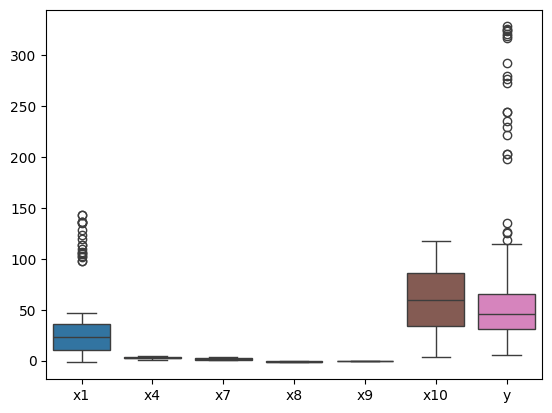

In [684]:
sns.boxplot(df_train)

In [685]:
# def handle_outliers_fixed(df):
#     numeric_cols = df.select_dtypes(include=['number']).columns
#     df_result = df.copy()

#     for col in numeric_cols:
#         Q1 = df_result[col].quantile(0.25)
#         Q3 = df_result[col].quantile(0.75)
#         IQR = Q3 - Q1
#         lower_bound = Q1 - 1.5 * IQR
#         upper_bound = Q3 + 1.5 * IQR

#         median_value = df_result[col].median()

#         # Penggantian nilai hanya pada kolom numerik
#         outlier_mask = (df_result[col] < lower_bound) | (df_result[col] > upper_bound)
#         df_result[col] = df_result[col].where(~outlier_mask, median_value)

#     return df_result

# df_train = handle_outliers_fixed(df_train)

Sebelumnya, saya telah menggunakan metode IQR untuk melakukan handle outlier, namun setelah saya bandingkan dengan menggunakan Z-Score, Hasil Evaluasi model lebih baik ketika handle outlier dengan Z-Score

In [686]:
z_scores = np.abs(stats.zscore(df_train[numeric_cols].fillna(df_train[numeric_cols].mean())))
df_train = df_train[(z_scores < 3).all(axis=1)].reset_index(drop=True)

$$
z = \frac{x - \mu}{\sigma}
$$

dengan:
- $x$ : nilai asli data  
- $\mu$ : rata-rata (mean) data  
- $\sigma$ : standar deviasi data  
- $z$ : nilai hasil scaling

<Axes: >

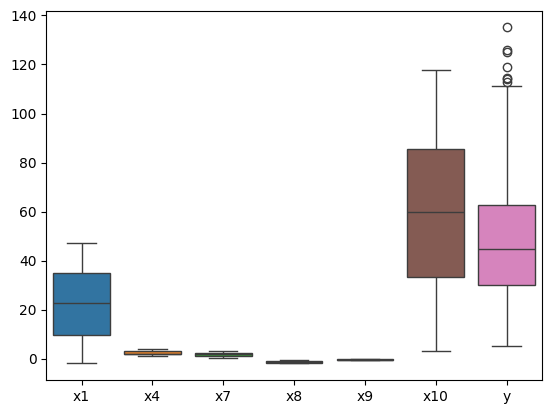

In [687]:
sns.boxplot(df_train)

In [688]:
df_train.isna().sum()

x1     43
x2     38
x3     38
x4     35
x5     42
x6     38
x7     39
x8     42
x9     35
x10    42
y      42
dtype: int64

## Cek Distribusi Data

array([[<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x7'}>],
       [<Axes: title={'center': 'x8'}>, <Axes: title={'center': 'x9'}>],
       [<Axes: title={'center': 'x10'}>, <Axes: >]], dtype=object)

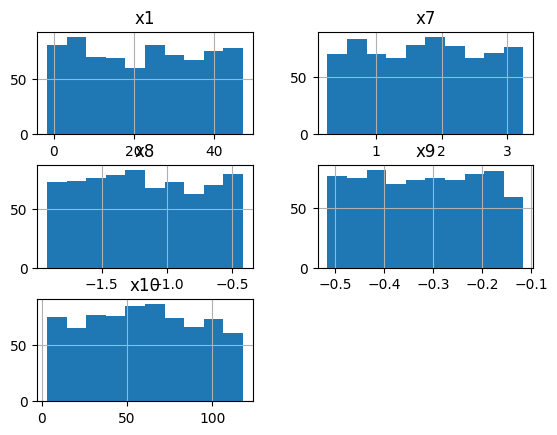

In [689]:
df_train[numeric_cols].hist()

Dilihat dari hasil visualisasi Histogram pada gambar di atas keseluruhan variabel bertipe data numerik memiliki distribusi yang cukup normal sehingga untuk melakukan imputasi pada missing value dapat menggunakan mean

## Handle Missing Value

In [690]:
df_train.isna().sum()

x1     43
x2     38
x3     38
x4     35
x5     42
x6     38
x7     39
x8     42
x9     35
x10    42
y      42
dtype: int64

In [691]:
df_test.isna().sum()

x1      7
x2     10
x3     11
x4     13
x5      8
x6     11
x7     10
x8      6
x9     12
x10     8
dtype: int64

### Handle Missing Value pada Variabel bertipe Data Numerik

In [692]:
df_train[numeric_cols] = df_train[numeric_cols].fillna(df_train[numeric_cols].mean())

In [693]:
df_train[numeric_cols].isna().sum()

x1     0
x7     0
x8     0
x9     0
x10    0
dtype: int64

In [694]:
df_test[numeric_cols] = df_test[numeric_cols].fillna(df_test[numeric_cols].mean())

In [695]:
df_test[numeric_cols].isna().sum()

x1     0
x7     0
x8     0
x9     0
x10    0
dtype: int64

### Handle Missing Value pada Variabel bertipe Data Kategorikal

Untuk menangani missing value pada variabel yang bertipe data kategorikal kita dapat menggunakan modus dari variabel tersebut

In [696]:
categorical_cols

['x2', 'x3', 'x5', 'x6', 'x4']

In [697]:
for col in categorical_cols :
    print(f'Jumlah Missing Value pada Data Training Variabel {col}: ', df_train[col].isna().sum())
print('===============================================================================')
for col in categorical_cols :
    print(f'Jumlah Missing Value pada Data Testing Variabel {col}: ', df_test[col].isna().sum())

Jumlah Missing Value pada Data Training Variabel x2:  38
Jumlah Missing Value pada Data Training Variabel x3:  38
Jumlah Missing Value pada Data Training Variabel x5:  42
Jumlah Missing Value pada Data Training Variabel x6:  38
Jumlah Missing Value pada Data Training Variabel x4:  35
Jumlah Missing Value pada Data Testing Variabel x2:  10
Jumlah Missing Value pada Data Testing Variabel x3:  11
Jumlah Missing Value pada Data Testing Variabel x5:  8
Jumlah Missing Value pada Data Testing Variabel x6:  11
Jumlah Missing Value pada Data Testing Variabel x4:  13


In [698]:
for col in categorical_cols :
    df_train[col] = df_train[col].fillna(df_train[col].mode().iloc[0])
    df_test[col] = df_test[col].fillna(df_test[col].mode().iloc[0])

In [699]:
for col in categorical_cols :
    print(f'Jumlah Missing Value pada Data Training Variabel {col}: ', df_train[col].isna().sum())
    print(f'Jumlah Missing Value pada Data Testing Variabel {col}: ', df_test[col].isna().sum())
    print('======')

Jumlah Missing Value pada Data Training Variabel x2:  0
Jumlah Missing Value pada Data Testing Variabel x2:  0
Jumlah Missing Value pada Data Training Variabel x3:  0
Jumlah Missing Value pada Data Testing Variabel x3:  0
Jumlah Missing Value pada Data Training Variabel x5:  0
Jumlah Missing Value pada Data Testing Variabel x5:  0
Jumlah Missing Value pada Data Training Variabel x6:  0
Jumlah Missing Value pada Data Testing Variabel x6:  0
Jumlah Missing Value pada Data Training Variabel x4:  0
Jumlah Missing Value pada Data Testing Variabel x4:  0


## Menghapus Missing Value pada Variabel Dependen

In [700]:
df_train = df_train.dropna(subset=['y']).reset_index(drop=True)

In [701]:
df_train.isna().sum()

x1     0
x2     0
x3     0
x4     0
x5     0
x6     0
x7     0
x8     0
x9     0
x10    0
y      0
dtype: int64

In [702]:
df_test.isna().sum()

x1     0
x2     0
x3     0
x4     0
x5     0
x6     0
x7     0
x8     0
x9     0
x10    0
dtype: int64

# Exploratory Data Analysis

## Cek Korelasi

Melakukan Analisis Korelasi untuk melihat variabel mana yang memiliki hubungan antara satu dengan yang lain

## Variabel Numerik

In [703]:
df_train[numeric_cols]

,x1,x7,x8,x9,x10
0,0.407166,1.127628,-0.657689,-0.415323,76.124758
1,44.417166,0.957628,-0.667689,-0.475323,85.834758
2,28.047166,0.717628,-1.107689,-0.385323,13.814758
3,-0.462834,1.717628,-1.547689,-0.425323,29.344758
4,42.957166,0.747628,-1.847689,-0.135323,59.447803
...,...,...,...,...,...
734,18.237166,2.857628,-1.727689,-0.435323,82.144758
735,37.787166,2.147628,-1.747689,-0.315323,32.374758
736,36.127166,0.437628,-0.857689,-0.185323,62.894758
737,32.477166,2.447628,-1.207689,-0.465323,77.094758


In [704]:
df_numeric_corr = df_train[['x1', 'x7', 'x8', 'x9', 'x10', 'y']].corr(method='pearson')
df_numeric_corr

,x1,x7,x8,x9,x10,y
x1,1.000000,0.058971,-0.083727,0.012923,-0.035945,0.681723
x7,0.058971,1.000000,-0.009954,-0.036357,-0.004846,0.041359
x8,-0.083727,-0.009954,1.000000,0.038089,0.009159,0.378532
x9,0.012923,-0.036357,0.038089,1.000000,-0.037423,0.289483
x10,-0.035945,-0.004846,0.009159,-0.037423,1.000000,0.343730
y,0.681723,0.041359,0.378532,0.289483,0.343730,1.000000


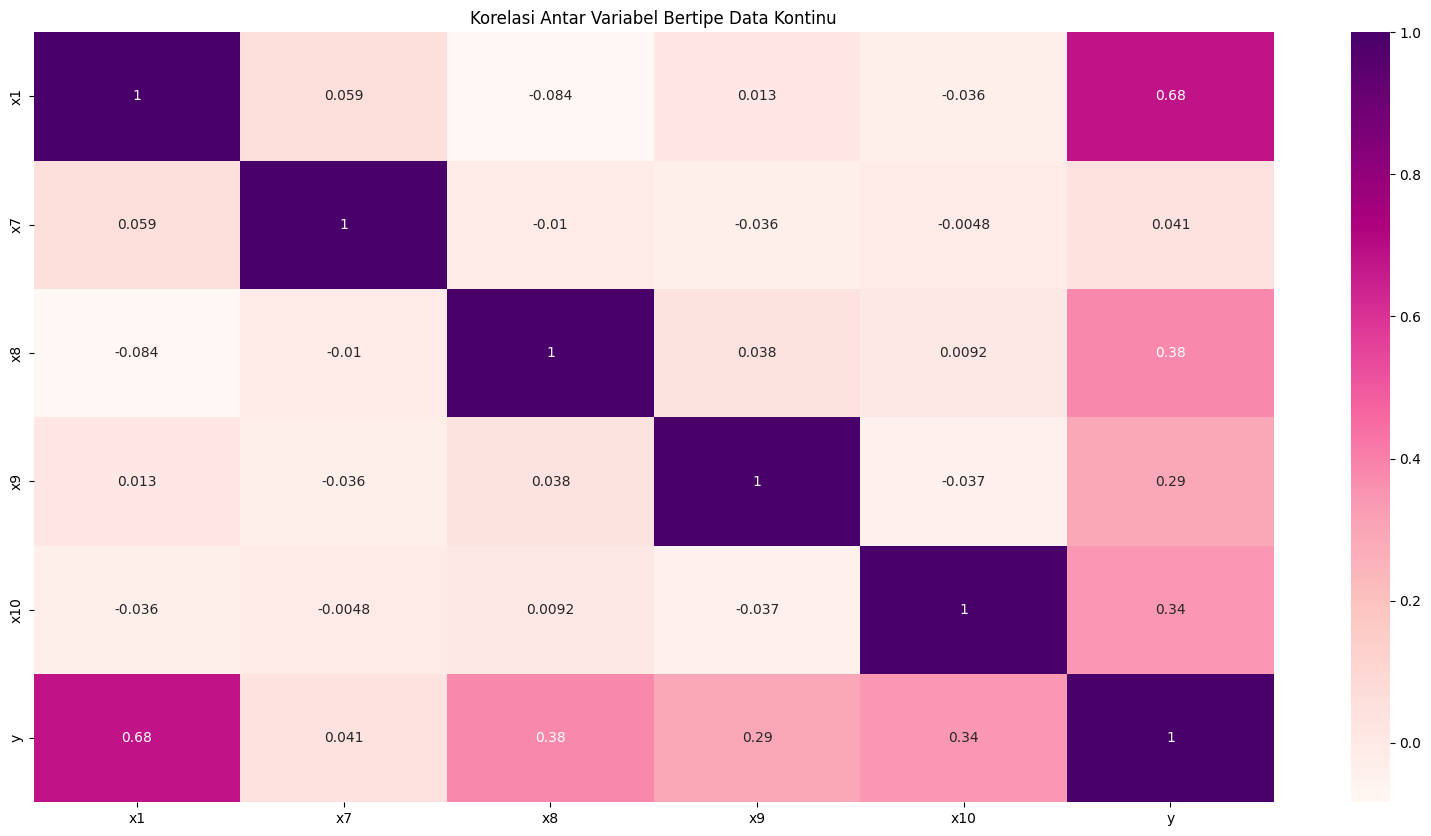

In [705]:
plt.figure(figsize=(20, 10))
plt.title('Korelasi Antar Variabel Bertipe Data Kontinu')
sns.heatmap(df_numeric_corr, annot=True, cmap='RdPu')
plt.show()

Berdasarkan visualisasi heatmap, terlihat bahwa variabel X7 tidak memiliki hubungan yang kuat dengan variabel Y, sehingga variabel X7 berpotensi untuk dihapus pada tahap feature Selection.

# Data Preprocessing

## Encode Data Bertipe Kategorikal

In [706]:
categorical_cols.pop()

'x4'

In [707]:
X_train_cat = pd.get_dummies(
    df_train[categorical_cols],
    drop_first=True,
    dtype='int64'
)

X_test_cat = pd.get_dummies(
    df_test[categorical_cols],
    drop_first=True,
    dtype='int64'
)

X_train_cat, X_test_cat = X_train_cat.align(
    X_test_cat,
    join='left',
    axis=1,
    fill_value=0
)

# Feature Engineering

In [708]:
y_train_transformed, lam = stats.boxcox(df_train['y'])

Box-Cox digunakan untuk melakukan transformasi pada variabel \(Y\) agar distribusi data menjadi lebih seimbang.

\(
\begin{cases}
\dfrac{Y^{\lambda} - 1}{\lambda}, & \text{jika } \lambda \neq 0 \\
\ln(Y), & \text{jika } \lambda = 0
\end{cases}
\)

## Mean Centering untuk Menghindari Multikolinearitas

In [709]:
train_mean = df_train[numeric_cols].mean()

df_train_centered = df_train[numeric_cols] - train_mean
df_test_centered = df_test[numeric_cols] - train_mean

## Mengubah Fungsi linear ke non-linear (Fungsi Polinomial)

In [710]:
from sklearn.preprocessing import PolynomialFeatures

In [711]:
poly = PolynomialFeatures(degree=2, include_bias=False)

Fungsi Polinomial derajat dua dilakukan untuk menambahkan fitur kuadrat dari setiap variabel prediktor sehingga model mampu menangkap pola yang non-linear, saya sudah melakukan percobaan terhadap fungsi polinomial derajat 3 dan 4 yang dihasilkan model overfitting, jadi disini saya menggunakan fungsi polinomial degree 2 yang artinya nanti nilai-nilai dari variabel prediktor akan ditransformasi ke bentuk kuadrat, sehingga rumus regresinya nanti akan seperti ini :
$$
y = \sum_{i=1}^{n} \beta_i x_i
+ \sum_{i=1}^{n} \beta_{ii} x_i^2
+ \varepsilon
$$

In [712]:
X_train_poly = poly.fit_transform(df_train_centered)
X_test_poly = poly.transform(df_test_centered)

In [713]:
X_train_final = np.hstack([X_train_poly, X_train_cat.values.astype(float)])
X_test_final = np.hstack([X_test_poly, X_test_cat.values.astype(float)])

## Scaling Data
Melakukan Scaling pada Variabel supaya skala data seragam
$$
z = \frac{x - \mu}{\sigma}
$$

dengan:
- $x$ : nilai asli data  
- $\mu$ : rata-rata (mean) data  
- $\sigma$ : standar deviasi data  
- $z$ : nilai hasil scaling

In [714]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

Pada scaling ini rumus yang digunakan sama dengan handle outlier, sama-sama menggunakan z-score. Perbedaan utamanya terletak pada tujuan, menghapus outlier dengan Z-Score adalah proses pembersihan untuk menghandle baris data ekstrem agar tidak merusak distribusi, sedangkan StandardScaler adalah proses transformasi untuk menyamakan skala fitur

# Modelling

Menambahkan konstanta pada fungsi regresi
$$
y = \beta_0
+ \sum_{i=1}^{n} \beta_i x_i
+ \sum_{i=1}^{n} \beta_{ii} x_i^2
+ \varepsilon
$$

In [715]:
X_train_constant = sm.add_constant(X_train_scaled_df)

In [716]:
model = sm.OLS(df_train['y'], X_train_constant).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     500.4
Date:                Thu, 01 Jan 2026   Prob (F-statistic):               0.00
Time:                        12:47:47   Log-Likelihood:                -2287.3
No. Observations:                 739   AIC:                             4631.
Df Residuals:                     711   BIC:                             4760.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         48.3929      0.200    241.408      0.0

Dapat dilihat pada Pelatihan Model pertama masih terdapat banyak variabel yang tidak signifikan sehingga diperlukan Feature Selection untuk menghapus Variabel mana yang tidak signifikan

### Backward Elimination untuk Menghapus Variabel Tidak Signifikan

In [717]:
def backward_elimination(data, target, significance_level=0.05):
    features = data.columns.tolist()
    while len(features) > 0:
        features_with_constant = sm.add_constant(data[features])
        model = sm.OLS(target, features_with_constant).fit()

        p_values = model.pvalues.drop('const')
        max_p_value = p_values.max()

        if max_p_value > significance_level:
            excluded_feature = p_values.idxmax()
            features.remove(excluded_feature)
            print(f"Menghapus Variabel: {excluded_feature} dengan (P-value: {max_p_value:.4f})")
        else:
            break
    return features, model

In [718]:
poly_names = poly.get_feature_names_out(numeric_cols)
cat_feature_names = X_train_cat.columns.tolist()
feature_names = list(poly_names) + cat_feature_names

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)
y_train_series = pd.Series(y_train_transformed).reset_index(drop=True)

selected_features, final_ols_model = backward_elimination(X_train_scaled_df, y_train_series)

Menghapus Variabel: x6_R dengan (P-value: 0.9481)
Menghapus Variabel: x7 x8 dengan (P-value: 0.8138)
Menghapus Variabel: x2_M dengan (P-value: 0.7579)
Menghapus Variabel: x5_L dengan (P-value: 0.5160)
Menghapus Variabel: x2_N dengan (P-value: 0.4713)
Menghapus Variabel: x2_E dengan (P-value: 0.4712)
Menghapus Variabel: x7 x10 dengan (P-value: 0.2980)
Menghapus Variabel: x7^2 dengan (P-value: 0.2384)
Menghapus Variabel: x7 x9 dengan (P-value: 0.2262)
Menghapus Variabel: x6_S dengan (P-value: 0.1971)
Menghapus Variabel: x5_M dengan (P-value: 0.1928)
Menghapus Variabel: x1 x7 dengan (P-value: 0.1366)


In [719]:
X_train_final = sm.add_constant(X_train_scaled_df[selected_features])

Menambahkan konstanta pada fungsi regresi
$$
y = \beta_0
+ \sum_{i=1}^{n} \beta_i x_i
+ \sum_{i=1}^{n} \beta_{ii} x_i^2
+ \varepsilon
$$

## Melatih Model Final dengan Seluruh Fitur yang Signifikan saja

In [720]:
model_final = sm.OLS(y_train_transformed, X_train_final).fit()
print(model_final.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     859.2
Date:                Thu, 01 Jan 2026   Prob (F-statistic):               0.00
Time:                        12:47:47   Log-Likelihood:                -871.10
No. Observations:                 739   AIC:                             1774.
Df Residuals:                     723   BIC:                             1848.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.2323      0.029    384.017      0.0

In [721]:
y_train_pred_box = model_final.predict(X_train_final)
y_train_pred_final = inv_boxcox(y_train_pred_box, lam)

# Evaluasi Model

In [722]:
r_squared = r2_score(df_train['y'], y_train_pred_final)
mse_train = mean_squared_error(df_train['y'], y_train_pred_final)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(df_train['y'], y_train_pred_final)

print(f"Hasil Evaluasi Model")
print(f"R-Squared  : {r_squared:.4f}")
print(f"MAE Train  : {mae_train:.4f}")
print(f"MSE Train  : {mse_train:.4f}")
print(f"RMSE Train : {rmse_train:.4f}")

Hasil Evaluasi Model
R-Squared  : 0.9476
MAE Train  : 2.6078
MSE Train  : 29.9432
RMSE Train : 5.4720


Setelah dilakukan proses pelatihan model dan evaluasi awal menggunakan data training dengan variabel X yang signifikan dihasilkan nilai MAE, MSE, RMSE, dan R-squared yang cukup baik.

# Uji Residual

In [723]:
residuals = final_ols_model.resid

## Uji Normalitas

In [724]:
stat, p_value = shapiro(residuals)
print(f"Uji Normalitas Shapiro-Wilk: Statistik={stat:.4f}, p-value={p_value}")
if p_value > 0.05:
    print("Residual terdistribusi normal")
else:
    print("Residual tidak normal")

Uji Normalitas Shapiro-Wilk: Statistik=0.6968, p-value=2.1410324531364764e-34
Residual tidak normal


Hasil uji Shapiro–Wilk menunjukkan nilai p-value = 2.1410324531364764e-34 mendekati 0 (< 0,05), sehingga H₀ ditolak. Artinya, residual tidak berdistribusi normal.

## Uji Multikolinearitas

In [725]:
poly_names = poly.get_feature_names_out(numeric_cols)
cat_feature_names = X_train_cat.columns.tolist()
feature_names = list(poly_names) + cat_feature_names

vif_df = pd.DataFrame()
vif_df["Feature"] = feature_names
vif_df["VIF"] = [
    variance_inflation_factor(X_train_scaled, i)
    for i in range(X_train_scaled.shape[1])
]

print("HASIL UJI MULTIKOLINEARITAS (VIF)")
print(vif_df.sort_values(by="VIF", ascending=False).to_string(index=False))

HASIL UJI MULTIKOLINEARITAS (VIF)
Feature      VIF
   x5_L 1.967787
   x5_M 1.944264
   x2_M 1.238067
   x2_E 1.233781
   x2_N 1.144691
 x1 x10 1.083941
     x1 1.061186
     x8 1.060921
  x1 x8 1.060770
 x8 x10 1.056996
   x7^2 1.052370
   x6_S 1.052016
   x6_R 1.050697
    x10 1.049032
  x1 x9 1.047271
  x8 x9 1.047165
  x10^2 1.044705
  x1 x7 1.044257
 x7 x10 1.043379
   x8^2 1.042533
     x9 1.039081
     x7 1.038140
   x1^2 1.033275
  x7 x9 1.032050
   x9^2 1.026108
 x9 x10 1.024029
  x7 x8 1.023231


Seluruh variabel independen terbebas dari masalah multikolinearitas karena memiliki nilai Variance Inflation Factor (VIF) yang sangat rendah. Nilai yang jauh di bawah ambang batas kritis 5 atau 10, yang mengindikasikan bahwa tidak ada korelasi antar variabel independen yang dapat mengganggu stabilitas model.

## Uji Heteroskedastisitas

In [726]:
bp_test = het_breuschpagan(residuals, X_train_constant)
labels = ['LM Stat', 'LM p-value', 'F-stat', 'F p-value']
bp_result = dict(zip(labels, bp_test))
print("\nUji Breusch-Pagan:", bp_result)
if bp_result['F p-value'] > 0.05:
    print("Tidak ada heteroskedastisitas")
else:
    print("Ada heteroskedastisitas")


Uji Breusch-Pagan: {'LM Stat': np.float64(27.00537972322643), 'LM p-value': np.float64(0.46350458082576057), 'F-stat': np.float64(0.9988020215216235), 'F p-value': np.float64(0.4675145642573093)}
Tidak ada heteroskedastisitas


Hasil uji heteroskedastisitas dengan breuschpagan menunjukkan bahwasannya signifikan nilai uji sebesar 0.46 (> 0.05) yang menunjukkan tidak adanya heteroskedastisitas

## Uji Autokorelasi

In [727]:
dw_stat = sm.stats.stattools.durbin_watson(residuals)
print(f"\nDurbin-Watson: {dw_stat:.3f}")


Durbin-Watson: 2.035


Hasil uji Durbin-Watson sebesar 2,035 menunjukkan bahwa tidak terdapat masalah autokorelasi yang signifikan dalam model regresi Anda.

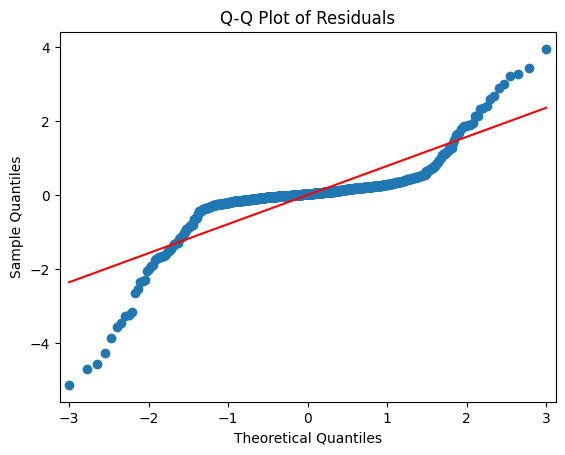

In [728]:
fig = sm.qqplot(residuals, line='s')

plt.title("Q-Q Plot of Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")

plt.show()

# Prediksi Variabel Target/Dependen Data Testing

In [729]:
# Prediksi Y Test
X_test_constant = sm.add_constant(X_test_scaled_df[selected_features])

In [730]:
y_test_pred = final_ols_model.predict(X_test_constant)
y_test_pred_inv = inv_boxcox(y_test_pred, lam)

In [731]:
df_result = pd.DataFrame({
    'ID': df_test.index.values + 1,
    'y': y_test_pred_inv
})
df_result.to_csv('submisson-revision.csv', index=False)

In [732]:
df_result

,ID,y
0,1,82.186758
1,2,79.032978
2,3,57.334095
3,4,83.302179
4,5,121.552299
...,...,...
188,189,99.576206
189,190,19.955742
190,191,9.847972
191,192,23.538386
